In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [6]:
df=pd.read_csv("C:\\Users\\USER\\Downloads\\Diabetic project\\diabetes cleaned Excel data.csv")

In [12]:
# basic data information with info(), describe(), head() 
df.head()

,id,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone,change_D,diabetesMed,readmitted,Age_Category
0,1,2278392,8222157.0,Caucasian,Female,[0-10),?,6,25,1,...,No,No,No,No,No,No,No,No,NO,Young
1,2,149190,55629189.0,Caucasian,Female,[10-20),?,1,1,7,...,Up,No,No,No,No,No,Ch,Yes,>30,Young
2,3,64410,86047875.0,AfricanAmerican,Female,[20-30),?,1,1,7,...,No,No,No,No,No,No,No,Yes,NO,Adult
3,4,500364,82442376.0,Caucasian,Male,[30-40),?,1,1,7,...,Up,No,No,No,No,No,Ch,Yes,NO,Adult
4,5,16680,42519267.0,Caucasian,Male,[40-50),?,1,1,7,...,Steady,No,No,No,No,No,Ch,Yes,NO,Adult


In [15]:
# replacing "?" with nan

df.replace("?",np.nan,inplace=True)

,id,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone,change_D,diabetesMed,readmitted,Age_Category
0,1,2278392,8222157.0,Caucasian,Female,[0-10),NaN,6,25,1,...,No,No,No,No,No,No,No,No,NO,Young
1,2,149190,55629189.0,Caucasian,Female,[10-20),NaN,1,1,7,...,Up,No,No,No,No,No,Ch,Yes,>30,Young
2,3,64410,86047875.0,AfricanAmerican,Female,[20-30),NaN,1,1,7,...,No,No,No,No,No,No,No,Yes,NO,Adult
3,4,500364,82442376.0,Caucasian,Male,[30-40),NaN,1,1,7,...,Up,No,No,No,No,No,Ch,Yes,NO,Adult
4,5,16680,42519267.0,Caucasian,Male,[40-50),NaN,1,1,7,...,Steady,No,No,No,No,No,Ch,Yes,NO,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,98994,407914478,NaN,Caucasian,Female,[60-70),NaN,1,3,7,...,No,No,No,No,No,No,Ch,Yes,NO,Adult
101762,99269,411384518,NaN,Caucasian,Female,[50-60),NaN,1,1,7,...,Up,No,No,No,No,No,Ch,Yes,NO,senior
101763,99358,412549274,NaN,Caucasian,Female,[60-70),NaN,2,3,1,...,No,No,No,No,No,No,No,Yes,NO,Adult
101764,100492,426670688,NaN,Caucasian,Female,[30-40),NaN,1,6,7,...,No,No,No,No,No,No,No,Yes,NO,Adult


In [17]:
# missing value analysis

df.isnull().sum().sort_values(ascending=False)

weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
patient_nbr                 30248
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
id                              0
encounter_id                    0
time_in_hospital                0
admission_source_id             0
num_procedures                  0
num_lab_procedures              0
admission_type_id               0
discharge_disposition_id        0
age                             0
gender                          0
number_inpatient                0
number_emergency                0
number_outpatient               0
num_medications                 0
number_diagnoses                0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride   

In [18]:
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

<Axes: xlabel='readmitted', ylabel='count'>

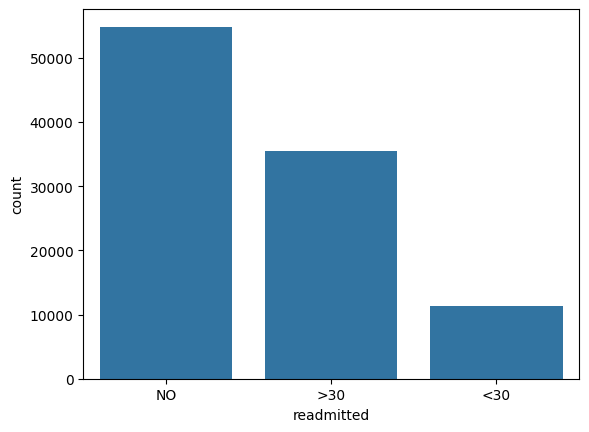

In [20]:
# Readmitted analyses with bar chart 

sns.countplot(x="readmitted",data=df)

<Axes: xlabel='gender', ylabel='count'>

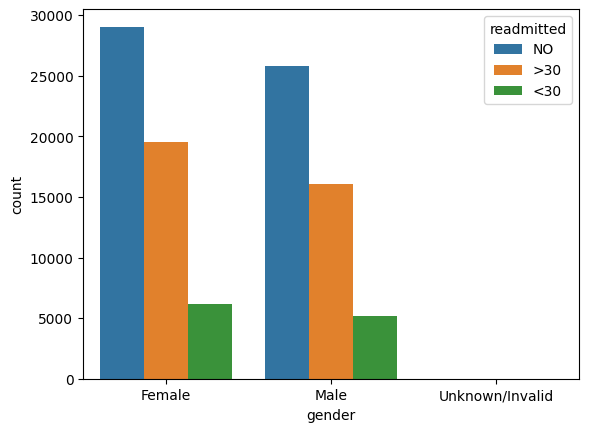

In [21]:
# Male vs Female readmoission 

sns.countplot(x="gender", hue = "readmitted" , data=df)

In [22]:
# Heat Map

pd.crosstab(df['age'],df['readmitted'])

readmitted,<30,>30,NO
age,,,
[0-10),3,26,132
[10-20),40,224,427
[20-30),236,510,911
[30-40),424,1187,2164
[40-50),1027,3278,5380
[50-60),1668,5917,9671
[60-70),2502,7897,12084
[70-80),3069,9475,13524
[80-90),2078,6223,8896


<Axes: xlabel='readmitted', ylabel='time_in_hospital'>

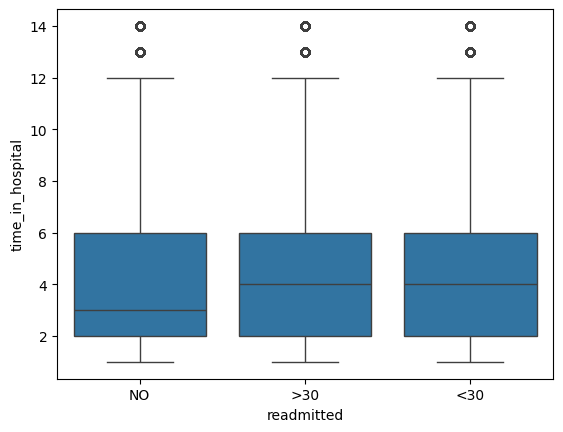

In [23]:
# hospital stay by readmission analyses with box plot 

sns.boxplot(x='readmitted', y='time_in_hospital',data=df)

<Axes: xlabel='num_medications', ylabel='time_in_hospital'>

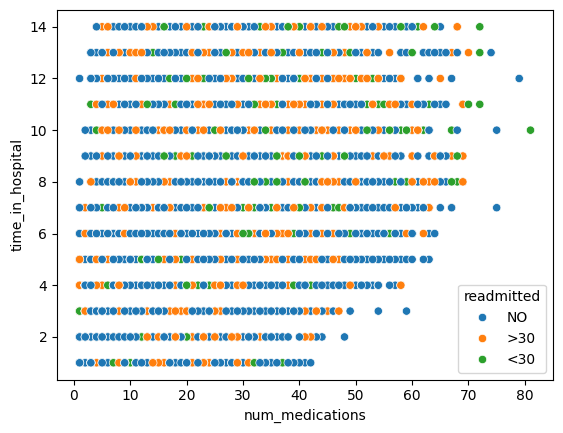

In [24]:
# Medication Analysis with scatterplot 

sns.scatterplot(
x='num_medications',
y='time_in_hospital',
hue='readmitted',
data=df
)

<Axes: >

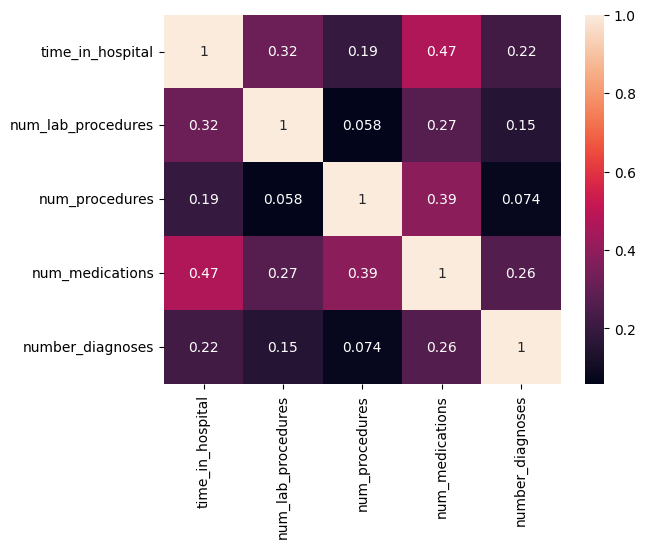

In [25]:
# Correlation Analysis with heatmap

corr=df[
['time_in_hospital',
'num_lab_procedures',
'num_procedures',
'num_medications',
'number_diagnoses']
].corr()

sns.heatmap(corr,annot=True)

In [26]:
#Insights :  1) Age group greater than 30 are more readmitting in hospitals
#            2) Females are more readmitting than woman 
#            3) 70-80 aged persons are high in readmission
#            4) avg stay is almost similar of all age groups only slight change is visible 

In [33]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "root"
password = quote_plus("Mani@123")
host= "localhost"
port= "3306"
database="diabetes_analysis"

engine= create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

df.to_sql(
    "diabetes",
    con=engine,
    if_exists="replace",
    index=False
)

101766